<a href="https://colab.research.google.com/github/halizahhhh/Tugas-Akhir-Siti-Nurhalizah/blob/main/Notebook_Analisis_Sentimen_IndoBERT_vs_TF_IDF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Perbandingan Kinerja IndoBERT dan TF-IDF dalam Mengklasifikasikan Sentimen Evaluasi Dosen Oleh Mahasiswa (EDOM) Menggunakan Algoritma K-Nearest Neighbor**

Notebook ini digunakan untuk melakukan proses analisis dan eksperimen dalam penelitian yang berfokus pada perbandingan dua teknik representasi teks, yaitu IndoBERT dan TF-IDF, dalam tugas klasifikasi sentimen komentar EDOM.

Tujuan Penelitian :
1. Membandingkan kinerja representasi teks IndoBERT dan TF-IDF dalam mengklasifikasikan sentimen pada data Evaluasi Dosen oleh Mahasiswa (EDOM).
2. Menentukan model klasifikasi sentimen yang paling optimal, dengan membandingkan kombinasi IndoBERT + KNN versus TF-IDF + KNN.



---



# **Import Library**

In [ ]:
# =============================
# 0. IMPORT & SETUP
# =============================
# Install (jika belum terpasang) jalankan di notebook:
!pip install transformers torch sastrawi imbalanced-learn seaborn google-generativeai tqdm

import os
import time
import re
import string
import json
from io import StringIO
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, precision_score, recall_score

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Sastrawi utilities
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

print("Libraries loaded. Torch device:", torch.device("cuda" if torch.cuda.is_available() else "cpu"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 10.3 MB/s eta 0:00:00
Libraries loaded. Torch device: cuda


# **1. Load Dataset**

In [ ]:
df = pd.read_excel('https://docs.google.com/uc?export=download&id=1ezxVT4D7mz7PpoZbaC3DHX2udrOT0RNq')
print("Total data:", len(df))

pd.set_option('display.max_rows', 10)  # hanya menampilkan sebagian (awal + akhir)
df

Total data: 14635


,Dosen,Semester,Komentar
0,RIZKIA NURINAYANTI,20241,Tidak ada
1,RIZKIA NURINAYANTI,20241,Semoga kedepannya lebih memperdqlam lagi ilmu ...
2,RIZKIA NURINAYANTI,20241,Mata kuliah yang cukup menarik dan harus diter...
3,RIZKIA NURINAYANTI,20241,Tidak ada
4,RIZKIA NURINAYANTI,20241,Pada mata kuliah ini saya diajarkan dalam memb...
...,...,...,...
14630,REZA MAULANA,20242,-
14631,REZA MAULANA,20242,sudah bagus
14632,REZA MAULANA,20242,.
14633,REZA MAULANA,20242,Dosen sangat menjelaskan materi dengan baik bu...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14635 entries, 0 to 14634
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Dosen     14635 non-null  object
 1   Semester  14635 non-null  int64 
 2   Komentar  14631 non-null  object
dtypes: int64(1), object(2)
memory usage: 343.1+ KB


# **2. Data Cleaning**

In [ ]:
# 2.1 Hapus duplikat berdasarkan kolom 'Komentar'
print("Jumlah duplikat komentar awal:", df['Komentar'].duplicated().sum())
df = df.drop_duplicates(subset='Komentar').reset_index(drop=True)
print("Setelah hapus duplikat:", len(df))

Jumlah duplikat komentar awal: 8984
Setelah hapus duplikat: 5651


In [ ]:
# 2.2 Hapus komentar tidak bermakna (fungsi kamu, dipertahankan logikanya)
def remove_undefined_text(text):
    if pd.isna(text):
        return None
    t = str(text).strip().lower()
    invalid = [
        '-', '.', ',', '..', '...', '', ' ','"."', '_', '__',
        'tidak ada', 'cukup', 'tidak', 'kosong', 'tidaj ada'
    ]
    if len(t) <= 3:
        return None
    if len(t.split()) <= 3 and t in invalid:
        return None
    return text

df['Komentar'] = df['Komentar'].apply(remove_undefined_text)
deleted_rows = df[df['Komentar'].isna()]
print("Jumlah data tidak bermakna yang dihapus:", len(deleted_rows))
df = df.dropna(subset=['Komentar']).reset_index(drop=True)
print("Jumlah data akhir setelah bersih:", len(df))

Jumlah data tidak bermakna yang dihapus: 36
Jumlah data akhir setelah bersih: 5615


In [ ]:
# 2.3 Hilangkan whitespace berlebih
df['Komentar'] = df['Komentar'].astype(str).str.strip()
df['Komentar'] = df['Komentar'].str.replace(r'\s+', ' ', regex=True)

In [ ]:
# Tampilkan beberapa contoh
display(df.head(5))

,Dosen,Semester,Komentar
0,RIZKIA NURINAYANTI,20241,Semoga kedepannya lebih memperdqlam lagi ilmu ...
1,RIZKIA NURINAYANTI,20241,Mata kuliah yang cukup menarik dan harus diter...
2,RIZKIA NURINAYANTI,20241,Pada mata kuliah ini saya diajarkan dalam memb...
3,RIZKIA NURINAYANTI,20241,"Penerapan nya udh bagus, jdi saya sebagai maha..."
4,RIZKIA NURINAYANTI,20241,Seru sih walaupun kadang bikin ngantuk karena ...


# **3. Preprocessing Teks**

In [ ]:
# 3.1 Kamus normalisasi
normalisasi = {
    "gk": "tidak", "ga": "tidak", "nggak": "tidak", "bgt": "banget", "bngt": "banget", "bener": "benar", "dosenny": "dosen nya", "mahasiswanya": "mahasiswa nya",
    "bgs": "bagus", "bagusss": "bagus", "baguss": "bagus", "bkin": "bikin", "bgin": "bikin", "bbrp": "beberapa", "dosenx": "dosen", "dosenya": "dosen", "mhs": "mahasiswa",
    "mhsw": "mahasiswa", "bnyk": "banyak", "bnk": "banyak", "banyakkk": "banyak", "krn": "karena", "krena": "karena", "karna": "karena", "jg": "juga", "jga": "juga", "jugaaa": "juga",
    "sbnrnya": "sebenarnya", "sbnr": "sebenarnya", "brrti": "berarti", "udh": "sudah", "udah": "sudah", "sdh": "sudah", "blm": "belum", "belomm": "belum",
    "kl": "kalau", "klo": "kalau", "klu": "kalau", "kalo": "kalau", "aj": "saja", "aja": "saja", "sj": "saja", "mksd": "maksud", "mksud": "maksud",
    "ngajar": "mengajar", "ngasih": "memberikan", "ngambil": "mengambil", "njelasin": "menjelaskan", "jelasin": "menjelaskan", "mantep": "mantap", "mantab": "mantap",
    "keren banget": "sangat baik", "baik banget": "sangat baik", "ok": "oke", "oke banget": "sangat baik", "lumayan kok": "cukup baik", "cukup baik lah": "cukup baik",
    "td": "tadi", "skr": "sekarang", "nnti": "nanti", "materinya": "materi", "penjelasannya": "penjelasan", "pembelajarannya": "pembelajaran", "tp": "tapi", "tpi": "tapi"
}

def normalize_text(text):
    text = text.lower()
    for key, value in normalisasi.items():
        text = re.sub(r"\b{}\b".format(re.escape(key)), value, text)
    return text

In [ ]:
# 3.2 Cleaning teks

def clean_text(text):
    # Case folding
    text = str(text).lower()
    # Hilangkan angka
    text = re.sub(r'\d+', ' ', text)
    # Hapus tanda baca
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Hapus simbol non-alfanumerik (jika masih ada)
    text = re.sub(r'[^\w\s]', ' ', text)
    # Normalisasi kata
    text = normalize_text(text)
    # Trim spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned'] = df['Komentar'].apply(clean_text)

In [ ]:
# 3.3 Tokenisasi sederhana (split by whitespace)
df['tokens'] = df['cleaned'].apply(lambda x: x.split())

In [ ]:
# 3.4 Stopword removal (Sastrawi)
stop_factory = StopWordRemoverFactory()
stopwords = set(stop_factory.get_stop_words())
df['stopwords_removed'] = df['tokens'].apply(lambda toks: [w for w in toks if w not in stopwords])

In [ ]:
# 3.5 Stemming (Sastrawi) - stem tiap kata unik sekali lalu mapping untuk efisiensi
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# kumpulkan kata unik
all_words = set(w for toks in df['stopwords_removed'] for w in toks)
print("Kata unik sebelum stemming:", len(all_words))

word_map = {}
for w in tqdm(all_words, desc="Stemming kata unik"):
    word_map[w] = stemmer.stem(w)

# Terapkan mapping ke setiap token list
df['stemming'] = df['stopwords_removed'].apply(lambda toks: [word_map[w] for w in toks])

Kata unik sebelum stemming: 4643


Stemming kata unik: 100%|██████████| 4643/4643 [05:25<00:00, 14.28it/s]


In [ ]:
# 3.5 Gabungkan kembali menjadi string untuk representasi
df['clean_text'] = df['stemming'].apply(lambda toks: " ".join(toks))

display(df[['Komentar', 'cleaned','tokens', 'stopwords_removed', 'stemming', 'clean_text']].head(5))

,Komentar,cleaned,tokens,stopwords_removed,stemming,clean_text
0,Semoga kedepannya lebih memperdqlam lagi ilmu ...,semoga kedepannya lebih memperdqlam lagi ilmu ...,"[semoga, kedepannya, lebih, memperdqlam, lagi,...","[semoga, kedepannya, lebih, memperdqlam, ilmu,...","[moga, depan, lebih, memperdqlam, ilmu, praktek]",moga depan lebih memperdqlam ilmu praktek
1,Mata kuliah yang cukup menarik dan harus diter...,mata kuliah yang cukup menarik dan harus diter...,"[mata, kuliah, yang, cukup, menarik, dan, haru...","[mata, kuliah, cukup, menarik, diterapkan, mah...","[mata, kuliah, cukup, tarik, terap, mahasiswa,...",mata kuliah cukup tarik terap mahasiswa baru
2,Pada mata kuliah ini saya diajarkan dalam memb...,pada mata kuliah ini saya diajarkan dalam memb...,"[pada, mata, kuliah, ini, saya, diajarkan, dal...","[mata, kuliah, diajarkan, membentuk, karakter,...","[mata, kuliah, ajar, bentuk, karakter, diri, m...",mata kuliah ajar bentuk karakter diri mata kul...
3,"Penerapan nya udh bagus, jdi saya sebagai maha...",penerapan nya sudah bagus jdi saya sebagai mah...,"[penerapan, nya, sudah, bagus, jdi, saya, seba...","[penerapan, nya, bagus, jdi, mahasiswa, pencer...","[terap, nya, bagus, jdi, mahasiswa, cerah, hid...",terap nya bagus jdi mahasiswa cerah hidup awal...
4,Seru sih walaupun kadang bikin ngantuk karena ...,seru sih walaupun kadang bikin ngantuk karena ...,"[seru, sih, walaupun, kadang, bikin, ngantuk, ...","[seru, sih, walaupun, kadang, bikin, ngantuk, ...","[seru, sih, walaupun, kadang, bikin, ngantuk, ...",seru sih walaupun kadang bikin ngantuk praktek...


# **4. Labelling**

In [ ]:
# install library
!pip install -q transformers

**4.1 Load Pretrained IndoBERT Sentiment Model (binary POS/NEG)**

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

SENTIMENT_MODEL_NAME = "agufsamudra/indo-sentiment-analysis"

tokenizer_sent = AutoTokenizer.from_pretrained(SENTIMENT_MODEL_NAME)
model_sent = AutoModelForSequenceClassification.from_pretrained(SENTIMENT_MODEL_NAME)

device = 0 if torch.cuda.is_available() else -1

sentiment_clf = pipeline(
    "text-classification",
    model=model_sent,
    tokenizer=tokenizer_sent,
    device=device
)

texts = df["clean_text"].tolist()
print("Jumlah komentar yang akan diprediksi:", len(texts))

# Pipeline memproses list teks (otomatis batch)
results = sentiment_clf(texts, batch_size=32, truncation=True)

# Simpan label mentah & skor confidence
df["sentiment_model_label_raw"] = [r["label"] for r in results]
df["sentiment_model_score"] = [r["score"] for r in results]

print("\nContoh hasil prediksi model (5 baris):")
display(
    df[
        ["clean_text", "sentiment_model_label_raw", "sentiment_model_score"]
    ].head()
)

Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Jumlah komentar yang akan diprediksi: 5615

Contoh hasil prediksi model (5 baris):


,clean_text,sentiment_model_label_raw,sentiment_model_score
0,moga depan lebih memperdqlam ilmu praktek,LABEL_1,0.956345
1,mata kuliah cukup tarik terap mahasiswa baru,LABEL_0,0.654456
2,mata kuliah ajar bentuk karakter diri mata kul...,LABEL_1,0.772452
3,terap nya bagus jdi mahasiswa cerah hidup awal...,LABEL_1,0.993756
4,seru sih walaupun kadang bikin ngantuk praktek...,LABEL_1,0.786041


**4.2 Mapping label model: positif/negatif**

In [ ]:
# Label unknown akan di drop unknown untuk modeling, balancing, dan encoding

def map_model_label_to_sentiment(label_str: str) -> str:
    l = label_str.lower()
    if "neg" in l or "0" in l:
        return "negatif"
    if "pos" in l or "1" in l:
        return "positif"
    return "unknown"

CONFIDENCE_THRESHOLD = 0.6

def final_sentiment_label(row):
    base = map_model_label_to_sentiment(row["sentiment_model_label_raw"])
    score = row["sentiment_model_score"]

    if score < CONFIDENCE_THRESHOLD:
        return "unknown"
    return base

df["sentiment_label"] = df.apply(final_sentiment_label, axis=1)

print("Distribusi label (termasuk unknown):")
print(df["sentiment_label"].value_counts())

Distribusi label (termasuk unknown):
sentiment_label
positif    3354
negatif    1841
unknown     420
Name: count, dtype: int64


In [ ]:
NO_FEEDBACK_KEYWORDS = ["masukan", "saran", "kritik", "kiritik", "komentar"]

def adjust_no_feedback_labels(row):
    t = row["clean_text"].lower()
    label = row["sentiment_label"]

    # jika mengandung "tidak ada + kata kunci"
    if "tidak ada" in t and any(k in t for k in NO_FEEDBACK_KEYWORDS):

        # jika ada kata positif → jadikan positif
        if "bagus" in t or "baik" in t or "cukup" in t:
            return "positif"

        # selain itu → tidak jelas → unknown
        return "unknown"

    return label

df["sentiment_label"] = df.apply(adjust_no_feedback_labels, axis=1)

print("Distribusi label setelah penyesuaian rule-based:")
print(df["sentiment_label"].value_counts())

Distribusi label setelah penyesuaian rule-based:
sentiment_label
positif    3354
negatif    1841
unknown     420
Name: count, dtype: int64


**4.3 Filter hanya positif & negatif, balancing, dan encoding**

In [ ]:
# Hanya gunakan data dengan label positif & negatif
df_labeled = df[df["sentiment_label"].isin(["positif", "negatif"])].copy()

print("Distribusi label setelah mengeluarkan 'unknown':")
print(df_labeled["sentiment_label"].value_counts())

# Balancing sederhana: undersampling kelas mayoritas
class_counts = df_labeled["sentiment_label"].value_counts()
min_count = class_counts.min()

print("\nJumlah data tiap kelas sebelum balancing:")
for label, count in class_counts.items():
    print(f" - {label}: {count}")

print("\nUkuran target tiap kelas setelah balancing (undersampling):", min_count)

dfs_balanced = []
for label in class_counts.index:
    sample = df_labeled[df_labeled["sentiment_label"] == label].sample(
        n=min_count, random_state=42
    )
    dfs_balanced.append(sample)

df_balanced = pd.concat(dfs_balanced).sample(frac=1, random_state=42).reset_index(drop=True)
print("\nDistribusi label setelah balancing:")
print(df_balanced["sentiment_label"].value_counts())

# Konversi label ke bentuk numerik (0/1) untuk modeling
# negatif = 0, positif = 1
label_mapping = {"negatif": 0, "positif": 1}
df_balanced["label"] = df_balanced["sentiment_label"].map(label_mapping)

print("\nContoh 10 baris data siap modeling:")
display(
    df_balanced[
        ["Komentar", "clean_text", "sentiment_model_label_raw",
         "sentiment_model_score", "sentiment_label", "label"]
    ].head(10)
)

Distribusi label setelah mengeluarkan 'unknown':
sentiment_label
positif    3354
negatif    1841
Name: count, dtype: int64

Jumlah data tiap kelas sebelum balancing:
 - positif: 3354
 - negatif: 1841

Ukuran target tiap kelas setelah balancing (undersampling): 1841

Distribusi label setelah balancing:
sentiment_label
negatif    1841
positif    1841
Name: count, dtype: int64

Contoh 10 baris data siap modeling:


,Komentar,clean_text,sentiment_model_label_raw,sentiment_model_score,sentiment_label,label
0,Mohon lebih sering memberikan feedback pada tu...,mohon lebih sering beri feedback tugastugas ma...,LABEL_0,0.729849,negatif,0
1,"Materi Jaringan Komputer cukup menarik, namun ...",materi jaring komputer cukup tarik sampai kura...,LABEL_0,0.964024,negatif,0
2,Mata Kuliah JKSI itu kurang bisa untuk membuat...,mata kuliah jksi kurang buat mahasiswa jadi ta...,LABEL_0,0.982587,negatif,0
3,Dosen udah ngejelasin dengan cukup jelas dan j...,dosen ngejelasin cukup jelas beri praktik sesu...,LABEL_1,0.806203,positif,1
4,menurut saya mata kuliah ini lumayan menarik b...,mata kuliah lumayan tarik buat,LABEL_1,0.871496,positif,1
5,"Terimakasih banyak pak, mungkin untuk mata kul...",terimakasih banyak pak mungkin mata kuliah usa...,LABEL_0,0.647373,negatif,0
6,terimkasih pak,terimkasih pak,LABEL_1,0.960598,positif,1
7,jangan terlalu cepat prateknya,jangan terlalu cepat prateknya,LABEL_0,0.939963,negatif,0
8,tentang pengenalannya materinya sangat luar bi...,kenal materi sangat luar biasa mulai nol sekali,LABEL_1,0.833217,positif,1
9,sebaiknya untuk si harus diberikAan dekripsi p...,baik si diberikaan dekripsi paham das matkul,LABEL_0,0.903405,negatif,0


**3.5 Simpan Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/grive')

# Simpan dataset hasil cleaning & labeling (file CSV)
OUTPUT_PATH = "/content/grive/My Drive/1.KULIAH/TA/data2/analisis/edom-2024-clean-balanced.csv"

# Ensure the directory exists before saving
import os
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

df_balanced.to_csv(OUTPUT_PATH, index=False)
print("Dataset cleaned & labeled tersimpan di:", OUTPUT_PATH)

Drive already mounted at /content/grive; to attempt to forcibly remount, call drive.mount("/content/grive", force_remount=True).
Dataset cleaned & labeled tersimpan di: /content/grive/My Drive/1.KULIAH/TA/data2/analisis/edom-2024-clean-balanced.csv


In [ ]:
# Simpan dataset hasil cleaning & labeling (file EXCEL)
OUTPUT_XLSX = "/content/grive/My Drive/1.KULIAH/TA/data2/analisis/edom-2024-clean-balanced.xlsx"

# Ensure the directory exists before saving
import os
os.makedirs(os.path.dirname(OUTPUT_XLSX), exist_ok=True)

df_balanced.to_excel(OUTPUT_XLSX, index=False)
print("Dataset cleaned & labeled tersimpan di:", OUTPUT_XLSX)

Dataset cleaned & labeled tersimpan di: /content/grive/My Drive/1.KULIAH/TA/data2/analisis/edom-2024-clean-balanced.xlsx


# **INDOBERT + KNN VS TF-IDF + KNN**

In [ ]:
import pandas as pd
from IPython.display import display

# load dataset
from google.colab import drive
drive.mount('/content/drive')

# Load dataset hasil preparation
DATASET_PATH = "/content/drive/MyDrive/1.KULIAH/TA/data2/analisis/edom-2024-clean-balanced.csv"

# Membaca dataset
df = pd.read_csv(DATASET_PATH)

print("Ukuran dataset:", df.shape)
print("\nNama kolom:")
print(df.columns.tolist())

print("\nLima baris pertama dataset:")
display(df.head())

# Kolom yang akan digunakan untuk modeling
TEXT_COLUMN = "clean_text"   # fitur teks
LABEL_COLUMN = "label"             # target numerik (0/1)

# Cek apakah kolom ada
for col in [TEXT_COLUMN, LABEL_COLUMN]:
    if col not in df.columns:
        raise ValueError(f"Kolom '{col}' tidak ditemukan di dataset. Sesuaikan nama kolomnya.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ukuran dataset: (3682, 12)

Nama kolom:
['Dosen', 'Semester', 'Komentar', 'cleaned', 'tokens', 'stopwords_removed', 'stemming', 'clean_text', 'sentiment_model_label_raw', 'sentiment_model_score', 'sentiment_label', 'label']

Lima baris pertama dataset:


,Dosen,Semester,Komentar,cleaned,tokens,stopwords_removed,stemming,clean_text,sentiment_model_label_raw,sentiment_model_score,sentiment_label,label
0,REZA PRIMARDIANSYAH,20241,Mohon lebih sering memberikan feedback pada tu...,mohon lebih sering memberikan feedback pada tu...,"['mohon', 'lebih', 'sering', 'memberikan', 'fe...","['mohon', 'lebih', 'sering', 'memberikan', 'fe...","['mohon', 'lebih', 'sering', 'beri', 'feedback...",mohon lebih sering beri feedback tugastugas ma...,LABEL_0,0.729849,negatif,0
1,Maulana Fakih Latief,20242,"Materi Jaringan Komputer cukup menarik, namun ...",materi jaringan komputer cukup menarik namun p...,"['materi', 'jaringan', 'komputer', 'cukup', 'm...","['materi', 'jaringan', 'komputer', 'cukup', 'm...","['materi', 'jaring', 'komputer', 'cukup', 'tar...",materi jaring komputer cukup tarik sampai kura...,LABEL_0,0.964024,negatif,0
2,SALMAN EL FARISI,20241,Mata Kuliah JKSI itu kurang bisa untuk membuat...,mata kuliah jksi itu kurang bisa untuk membuat...,"['mata', 'kuliah', 'jksi', 'itu', 'kurang', 'b...","['mata', 'kuliah', 'jksi', 'kurang', 'membuat'...","['mata', 'kuliah', 'jksi', 'kurang', 'buat', '...",mata kuliah jksi kurang buat mahasiswa jadi ta...,LABEL_0,0.982587,negatif,0
3,Maulana Fakih Latief,20242,Dosen udah ngejelasin dengan cukup jelas dan j...,dosen sudah ngejelasin dengan cukup jelas dan ...,"['dosen', 'sudah', 'ngejelasin', 'dengan', 'cu...","['dosen', 'ngejelasin', 'cukup', 'jelas', 'mem...","['dosen', 'ngejelasin', 'cukup', 'jelas', 'ber...",dosen ngejelasin cukup jelas beri praktik sesu...,LABEL_1,0.806203,positif,1
4,AHMAD RIO ADRIANSYAH,20241,menurut saya mata kuliah ini lumayan menarik b...,menurut saya mata kuliah ini lumayan menarik b...,"['menurut', 'saya', 'mata', 'kuliah', 'ini', '...","['mata', 'kuliah', 'lumayan', 'menarik', 'buat']","['mata', 'kuliah', 'lumayan', 'tarik', 'buat']",mata kuliah lumayan tarik buat,LABEL_1,0.871496,positif,1


# **Mengubah Kolom Dosen Menjadi Anonym**

In [ ]:
def anonymize_column(df, column_name, prefix):
    """
    Mengubah isi kolom menjadi samaran konsisten.
    Contoh:
    Ahmad Fauzi → Dosen_01
    Ahmad Fauzi (muncul lagi) → Dosen_01
    """

    unique_values = df[column_name].dropna().unique()

    mapping = {
        name: f"{str(i+1).zfill(2)}"
        for i, name in enumerate(unique_values)
    }

    df[column_name] = df[column_name].map(mapping)

    return df, mapping

df, dosen_mapping = anonymize_column(
    df,
    column_name="Dosen",
    prefix="Nama_Dosen"
)

df.head()

,Dosen,Semester,Komentar,cleaned,tokens,stopwords_removed,stemming,clean_text,sentiment_model_label_raw,sentiment_model_score,sentiment_label,label
0,01,20241,Mohon lebih sering memberikan feedback pada tu...,mohon lebih sering memberikan feedback pada tu...,"['mohon', 'lebih', 'sering', 'memberikan', 'fe...","['mohon', 'lebih', 'sering', 'memberikan', 'fe...","['mohon', 'lebih', 'sering', 'beri', 'feedback...",mohon lebih sering beri feedback tugastugas ma...,LABEL_0,0.729849,negatif,0
1,02,20242,"Materi Jaringan Komputer cukup menarik, namun ...",materi jaringan komputer cukup menarik namun p...,"['materi', 'jaringan', 'komputer', 'cukup', 'm...","['materi', 'jaringan', 'komputer', 'cukup', 'm...","['materi', 'jaring', 'komputer', 'cukup', 'tar...",materi jaring komputer cukup tarik sampai kura...,LABEL_0,0.964024,negatif,0
2,03,20241,Mata Kuliah JKSI itu kurang bisa untuk membuat...,mata kuliah jksi itu kurang bisa untuk membuat...,"['mata', 'kuliah', 'jksi', 'itu', 'kurang', 'b...","['mata', 'kuliah', 'jksi', 'kurang', 'membuat'...","['mata', 'kuliah', 'jksi', 'kurang', 'buat', '...",mata kuliah jksi kurang buat mahasiswa jadi ta...,LABEL_0,0.982587,negatif,0
3,02,20242,Dosen udah ngejelasin dengan cukup jelas dan j...,dosen sudah ngejelasin dengan cukup jelas dan ...,"['dosen', 'sudah', 'ngejelasin', 'dengan', 'cu...","['dosen', 'ngejelasin', 'cukup', 'jelas', 'mem...","['dosen', 'ngejelasin', 'cukup', 'jelas', 'ber...",dosen ngejelasin cukup jelas beri praktik sesu...,LABEL_1,0.806203,positif,1
4,04,20241,menurut saya mata kuliah ini lumayan menarik b...,menurut saya mata kuliah ini lumayan menarik b...,"['menurut', 'saya', 'mata', 'kuliah', 'ini', '...","['mata', 'kuliah', 'lumayan', 'menarik', 'buat']","['mata', 'kuliah', 'lumayan', 'tarik', 'buat']",mata kuliah lumayan tarik buat,LABEL_1,0.871496,positif,1


# **Split Data**

In [ ]:
from sklearn.model_selection import train_test_split

# Fitur teks dan target
X_text = df[TEXT_COLUMN].astype(str).tolist()
y = df[LABEL_COLUMN].astype(int)

# Bagi data train dan test (80:20)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # supaya proporsi kelas seimbang di train & test
)

print("Jumlah data training :", len(X_train_text))
print("Jumlah data testing  :", len(X_test_text))

Jumlah data training : 2945
Jumlah data testing  : 737


# **Representasi TF-IDF**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# === TF-IDF TRAINING ===
tfidf = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=2,              # kata yang muncul min 2x
    max_df=0.9             # abaikan kata yang terlalu umum
)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("TF-IDF shape train:", X_train_tfidf.shape, "test:", X_test_tfidf.shape)

# Tampilkan matriks TF-IDF untuk 4 baris pertama
#df_tfidf_preview = pd.DataFrame(X_train_tfidf[:4].toarray(),columns=tfidf.get_feature_names_out())

#print("\nContoh 4 baris pertama matriks TF-IDF:")
#display(df_tfidf_preview.head())

# === TABEL TF-IDF PER KOLOM UNTUK BARIS 1-3 ===
df_full = pd.DataFrame(X_train_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Pilih baris 1, 2, 3 (index 0-2)
tfidf_rows_subset = df_full.iloc[:3]

print("\n=== Nilai TF-IDF Non-Nol untuk Baris 1, 2, dan 3 ===")

for index, row in tfidf_rows_subset.iterrows():
    non_zero_values = row[row != 0.0]

    print(f"\nBaris ke-{index + 1}:")
    if not non_zero_values.empty:
        tfidf_table = non_zero_values.reset_index()
        tfidf_table.columns = ['Kata', 'Hasil Perhitungan TF-IDF']
        print(tfidf_table.to_markdown(index=False, floatfmt=".4f"))
    else:
        print("Tidak ada nilai TF-IDF non-nol.")

TF-IDF shape train: (2945, 1171) test: (737, 1171)

=== Nilai TF-IDF Non-Nol untuk Baris 1, 2, dan 3 ===

Baris ke-1:
| Kata       |   Hasil Perhitungan TF-IDF |
|:-----------|---------------------------:|
| atas       |                     0.3793 |
| pak        |                     0.2712 |
| satu       |                     0.4204 |
| semester   |                     0.3748 |
| terimaksih |                     0.6822 |

Baris ke-2:
| Kata    |   Hasil Perhitungan TF-IDF |
|:--------|---------------------------:|
| giat    |                     0.4368 |
| jadwal  |                     0.3948 |
| mohon   |                     0.3430 |
| pribadi |                     0.4021 |
| saran   |                     0.2170 |
| sistem  |                     0.3254 |
| timbang |                     0.4701 |

Baris ke-3:
| Kata     |   Hasil Perhitungan TF-IDF |
|:---------|---------------------------:|
| bikin    |                     0.3953 |
| dosen    |                     0.2040 |
| friendly 

## **Persebaran Term Frequency (TF)**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Inisialisasi CountVectorizer
count_vectorizer = CountVectorizer()

# Transform data latih
X_train_tf = count_vectorizer.fit_transform(X_train_text)

# Total frekuensi kata di seluruh dokumen (TF mentah)
tf_sum = X_train_tf.sum(axis=0).A1

# Total kata per dokumen
total_terms_per_doc = X_train_tf.sum(axis=1)

# Hitung TF ternormalisasi per dokumen
tf_normalized = X_train_tf.multiply(1 / total_terms_per_doc)

# Rata-rata TF per kata di seluruh dokumen
tf_score = tf_normalized.mean(axis=0).A1

# Membuat DataFrame
df_tf = pd.DataFrame({
    "Kata": count_vectorizer.get_feature_names_out(),
    "Total_Term_Frequency": tf_sum,
    "Skor_TF": tf_score
}).sort_values("Total_Term_Frequency", ascending=False)

# Menampilkan 15 kata teratas
df_tf.head(15)

,Kata,Total_Term_Frequency,Skor_TF
1176,lebih,835,0.030814
1298,materi,778,0.026726
50,ajar,759,0.027149
199,baik,717,0.038233
1119,kuliah,599,0.019143
890,jelas,594,0.022274
1939,sangat,594,0.025344
552,dosen,523,0.018581
1235,mahasiswa,508,0.013145
1292,mata,496,0.015643


## **Persebaran Inverse Document Frequency (IDF)**

In [ ]:
# Mengambil nilai IDF dari objek TF-IDF Vectorizer
idf_values = tfidf.idf_

# Membuat DataFrame
df_idf = pd.DataFrame({
    "Kata": tfidf.get_feature_names_out(),
    "Skor_IDF": idf_values,
    "Jumlah_Dokumen (DF)": (X_train_tfidf > 0).sum(axis=0).A1
})

# SORT BERDASARKAN SKOR IDF TERTINGGI
df_idf_tertinggi = df_idf.sort_values(
    "Skor_IDF", ascending=False
)

# Tampilkan 15 kata dengan IDF tertinggi
df_idf_tertinggi.head(15)

,Kata,Skor_IDF,Jumlah_Dokumen (DF)
20,akademik,7.889591,2
15,ahli,7.889591,2
0,aamiin,7.889591,2
38,ama,7.889591,2
741,pahamin,7.889591,2
721,objektif,7.889591,2
694,ngelola,7.889591,2
748,pandang,7.889591,2
736,pada,7.889591,2
702,ni,7.889591,2


## **Total TF-IDF**

In [ ]:
idx = 0

# 1. Ambil teks asli dari X_train (bukan dari df awal agar tidak tertukar indeksnya)
teks_asli = X_train_text[idx]

# 2. Ambil baris TF-IDF yang sesuai
sample_tfidf_row = X_train_tfidf[idx]

# 3. Buat DataFrame bobot
df_sample = pd.DataFrame({
    "Kata": tfidf.get_feature_names_out(),
    "Bobot_TF-IDF": sample_tfidf_row.toarray().flatten()
})

# 4. Filter dan urutkan
df_sample = df_sample[df_sample["Bobot_TF-IDF"] > 0].sort_values("Bobot_TF-IDF", ascending=False)

print(f"Komentar Riil di Indeks {idx}:\n'{teks_asli}'")
print("\nBobot TF-IDF yang Terdeteksi:")
print(df_sample.to_string(index=False))

Komentar Riil di Indeks 0:
'terimaksih pak atas satu semester'

Bobot TF-IDF yang Terdeteksi:
      Kata  Bobot_TF-IDF
terimaksih      0.682228
      satu      0.420374
      atas      0.379262
  semester      0.374774
       pak      0.271212


## **WordCloud Perhitungan TF-IDF**

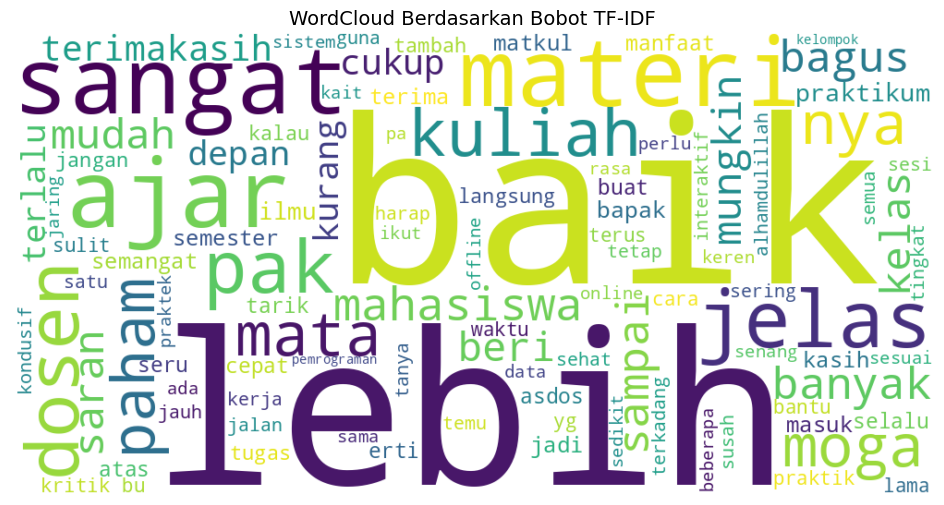

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# === HITUNG TOTAL BOBOT TF-IDF ===
tfidf_scores = X_train_tfidf.sum(axis=0).A1

tfidf_dict = dict(
    zip(tfidf.get_feature_names_out(), tfidf_scores)
)

# === WORDCLOUD ===
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100,
    colormap='viridis'
).generate_from_frequencies(tfidf_dict)

plt.figure(figsize=(15,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud Berdasarkan Bobot TF-IDF", fontsize=14)
plt.show()

# **Representasi IndoBERT**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "indobenchmark/indobert-base-p2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()
print("Loaded IndoBERT on", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loaded IndoBERT on cuda


In [ ]:
def embed_texts_batched(texts, batch_size=32, max_length=128, token_sample_n=2):
    pooled = []
    # token_tables: menyimpan tabel token-level untuk beberapa sampel (hanya untuk ditampilkan)
    token_tables = {}

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        # Tokenisasi batch (padding + truncation)
        enc = tokenizer(batch, return_tensors='pt', padding=True, truncation=True, max_length=max_length).to(device)

        # Non-gradient karena hanya inference
        with torch.no_grad():
            out = model(**enc)

         # Ambil hidden state terakhir (B, seq_len, hidden_dim)
        last_hidden = out.last_hidden_state.cpu().numpy()  # shape (B, seq_len, hidden)

        # Attention mask untuk tahu posisi token asli (bukan padding)
        masks = enc['attention_mask'].cpu().numpy()
        for b_idx in range(len(batch)):
            seq = last_hidden[b_idx]
            mask = masks[b_idx]

            if mask.sum() > 0:
                pooled_vec = (seq * mask[:, None]).sum(axis=0) / mask.sum()
            else:
                pooled_vec = seq.mean(axis=0)
            pooled.append(pooled_vec)

        # Buat token-level table (hanya untuk sampel pertama batch 1)
        # token_sample_n menentukan berapa sample yang ditampilkan
        if i == 0:
            for j in range(min(token_sample_n, len(batch))):
                token_ids = enc['input_ids'][j].cpu().numpy()
                tokens = tokenizer.convert_ids_to_tokens(token_ids)
                seq_j = last_hidden[j]
                dims_show = min(8, seq_j.shape[1])

                data = []
                for t_i, tok in enumerate(tokens):
                    row = [tok] + list(seq_j[t_i,:dims_show]) + [float(np.linalg.norm(seq_j[t_i]))]
                    data.append(row)

                cols = ['token'] + [f'dim_{d}' for d in range(dims_show)] + ['l2_norm']
                token_tables[j] = pd.DataFrame(data, columns=cols)
    return np.vstack(pooled), token_tables

# ============================================================
#          JALANKAN PROSES EMBEDDING TRAIN & TEST
# ============================================================
# --------------- EMBEDDING TRAIN ---------------
start = time.time()
X_train_bert, token_tables_train = embed_texts_batched(X_train_text, batch_size=32, token_sample_n=2)
end_train = time.time()
print(f"Embedding for train data done in {end_train-start:.1f}s; shape:", X_train_bert.shape)

# --------------- EMBEDDING TEST ---------------
start = time.time()
X_test_bert, _ = embed_texts_batched(X_test_text, batch_size=32, token_sample_n=0) # token_sample_n=0 to avoid re-generating tables
end_test = time.time()
print(f"Embedding for test data done in {end_test-start:.1f}s; shape:", X_test_bert.shape)

# ============================================================
#      TAMPILKAN TOKEN-LEVEL TABLE (2 SAMPLE PERTAMA)
# ============================================================
for k,v in token_tables_train.items():
    print(f"\nToken-level table sample {k} (from train data):")
    display(v.head(10))

Embedding for train data done in 8.3s; shape: (2945, 768)
Embedding for test data done in 1.9s; shape: (737, 768)

Token-level table sample 0 (from train data):


,token,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,l2_norm
0,[CLS],0.186166,2.096234,-0.081580,1.014667,2.770940,-1.115505,-0.013790,-0.247865,27.918510
1,terima,-0.184996,1.483653,0.225211,0.698091,0.052250,-0.497123,0.209929,-0.191147,27.745840
2,##ks,0.945729,0.751657,0.583242,0.142401,0.833037,-0.360775,-0.469920,-0.982391,27.679726
3,##ih,-0.728081,1.140673,0.730135,0.381843,-0.352055,-0.573419,-0.875670,-0.064376,27.842930
4,pak,-0.117236,1.671739,0.141957,-0.987391,0.930165,-0.066419,-2.017137,0.466096,27.884546
5,atas,-0.144383,2.172180,1.407776,-0.900310,0.188777,0.639646,-1.260102,1.114298,27.878342
6,satu,-0.325620,2.548094,0.680056,-0.640770,0.824571,-0.236788,-0.585176,1.693383,27.872847
7,semester,-0.651772,0.658580,-0.356856,-1.067942,1.419057,-0.321807,-0.225032,0.778208,27.904449
8,[SEP],-0.138598,1.170714,0.823514,-0.054859,1.661335,-0.270788,-0.962271,0.507519,28.091286
9,[PAD],0.033072,1.343132,0.878922,1.183281,0.808930,-0.676104,-0.571514,0.862633,27.981684



Token-level table sample 1 (from train data):


,token,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,l2_norm
0,[CLS],1.305252,2.415057,0.425199,0.699892,2.718691,-1.235045,-0.020655,-0.458358,27.890249
1,saran,0.293748,1.427326,3.127952,0.004368,1.684446,-0.124790,-0.667733,1.410516,27.987989
2,sistem,0.141838,1.654845,2.706755,-0.307494,1.705041,0.418808,-1.535388,1.319019,27.974365
3,jadwal,0.234396,1.181196,1.615995,-0.551230,0.454766,0.874819,-1.215943,0.101887,27.976608
4,mohon,0.310917,0.979637,-0.378759,0.880911,0.685651,-0.103331,0.153361,1.623911,28.007483
5,timbang,-0.307419,1.686378,1.520018,-0.897485,0.543033,0.750707,-0.392170,1.255346,27.987898
6,bentrok,0.212110,0.886101,0.461135,1.016630,1.651982,0.493323,-0.181110,0.049100,28.011196
7,giat,1.024760,1.732991,-0.717513,1.378346,-0.486451,0.282642,-0.436612,0.605639,27.970583
8,pribadi,1.095532,1.992409,0.692997,0.497521,2.045868,-0.105219,-0.364594,-0.775231,28.004456
9,[SEP],0.580348,1.451295,0.906403,0.378558,2.067512,-0.663986,-0.480506,0.421612,28.090223


## **Contoh Embedding 1 Komentar**

In [ ]:
#Ambil 1 contoh komentar
sample_text = X_train_text[1]
print("Komentar contoh:")
print(sample_text)

#Tokenisasi & embedding satu komentar
enc = tokenizer(
    sample_text,
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=128
).to(device)

with torch.no_grad():
    out = model(**enc)

last_hidden = out.last_hidden_state.cpu().numpy()[0]
mask = enc['attention_mask'].cpu().numpy()[0]
tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'][0])

#Tabel hasil Embedding
rows = []
for i, tok in enumerate(tokens):
    if mask[i] == 1:
        rows.append({
            "Token": tok,
            "Contoh Nilai (3 dimensi)": last_hidden[i][:3],
            "Panjang Vektor (L2 Norm)": np.linalg.norm(last_hidden[i])
        })

df_explain = pd.DataFrame(rows)
display(df_explain)

#Hitung Embedding Kalimat(Rata-rata)
sentence_embedding = (last_hidden * mask[:, None]).sum(axis=0) / mask.sum()

print("Embedding kalimat (5 dimensi pertama):")
print(sentence_embedding[:5])
print("\nPanjang vektor embedding kalimat:", np.linalg.norm(sentence_embedding))

Komentar contoh:
saran sistem jadwal mohon timbang bentrok giat pribadi


,Token,Contoh Nilai (3 dimensi),Panjang Vektor (L2 Norm)
0,[CLS],"[1.3052518, 2.4150581, 0.42519823]",27.890251
1,saran,"[0.2937478, 1.4273262, 3.1279526]",27.987989
2,sistem,"[0.14183742, 1.6548457, 2.7067547]",27.974365
3,jadwal,"[0.23439583, 1.1811959, 1.6159943]",27.976606
4,mohon,"[0.31091592, 0.979637, -0.37875938]",28.007481
5,timbang,"[-0.3074194, 1.6863796, 1.5200175]",27.987898
6,bentrok,"[0.21210995, 0.88610095, 0.46113542]",28.011196
7,giat,"[1.0247587, 1.7329912, -0.71751195]",27.970581
8,pribadi,"[1.0955318, 1.9924082, 0.6929964]",28.004456
9,[SEP],"[0.58034676, 1.451295, 0.9064023]",28.090223


Embedding kalimat (5 dimensi pertama):
[0.48914767 1.54072378 1.03601801 0.31000196 1.30705418]

Panjang vektor embedding kalimat: 19.998741048134573


# **Evaluasi Model**

## **TF-IDF + KNN**

=== Evaluasi KNN (Cross-Validation f1_macro) ===
K =  1 | mean f1_macro = 0.7330
K =  3 | mean f1_macro = 0.7443
K =  5 | mean f1_macro = 0.7412
K =  7 | mean f1_macro = 0.7318
K =  9 | mean f1_macro = 0.7304
K = 11 | mean f1_macro = 0.7125
K = 13 | mean f1_macro = 0.6984
K = 15 | mean f1_macro = 0.6897
K = 17 | mean f1_macro = 0.6758
K = 19 | mean f1_macro = 0.7487
K = 21 | mean f1_macro = 0.7722
K = 23 | mean f1_macro = 0.7790
K = 25 | mean f1_macro = 0.8095
K = 27 | mean f1_macro = 0.8150
K = 29 | mean f1_macro = 0.8239
K = 31 | mean f1_macro = 0.8297

=== K TERBAIK (Cross-Validation) ===
Best K  : 31
Best CV f1_macro : 0.8297

Best K TF-IDF: 31


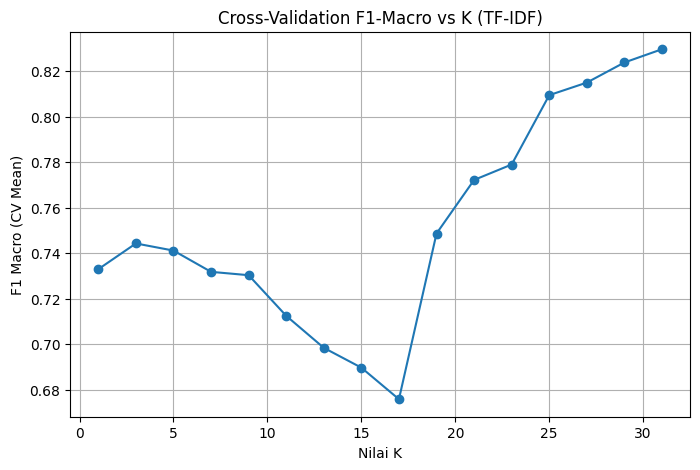

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# ======================================================
# Fungsi: Mencari nilai K terbaik memakai Cross-Validation
# ======================================================
def select_best_k_cv(X_train, y_train, k_list, cv=5):
    best_k = None
    best_score = -1
    scores_mean = {}

    print("=== Evaluasi KNN (Cross-Validation f1_macro) ===")

    for k in k_list:
        model = KNeighborsClassifier(n_neighbors=k)

        scores = cross_val_score(
            model, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1
        )

        mean_score = scores.mean()
        scores_mean[k] = mean_score

        print(f"K = {k:2d} | mean f1_macro = {mean_score:.4f}")

        if mean_score > best_score:
            best_score = mean_score
            best_k = k

    print("\n=== K TERBAIK (Cross-Validation) ===")
    print(f"Best K  : {best_k}")
    print(f"Best CV f1_macro : {best_score:.4f}")

    return best_k, scores_mean


# ======================================================
# 1. Daftar nilai K (ambil hanya yang ganjil)
# ======================================================
k_list = list(range(1, 32, 2))  # K = 1,3,5,...31

# ======================================================
# 2. Jalankan untuk TF-IDF
# ======================================================
best_k_tfidf, scores_tfidf = select_best_k_cv(
    X_train_tfidf, y_train, k_list)

print("\nBest K TF-IDF:", best_k_tfidf)

# =============================
# 3. Plot hasil CV untuk visualisasi
# =============================
plt.figure(figsize=(8, 5))
plt.plot(list(scores_tfidf.keys()), list(scores_tfidf.values()), marker='o')
plt.xlabel("Nilai K")
plt.ylabel("F1 Macro (CV Mean)")
plt.title("Cross-Validation F1-Macro vs K (TF-IDF)")
plt.grid(True)
plt.show()

TF-IDF + KNN — Accuracy: 0.8208955223880597
F1 macro: 0.8177383093525179

=== Classification Report (TF-IDF + KNN) ===
              precision    recall  f1-score   support

         neg       0.75      0.95      0.84       369
         pos       0.93      0.69      0.79       368

    accuracy                           0.82       737
   macro avg       0.84      0.82      0.82       737
weighted avg       0.84      0.82      0.82       737



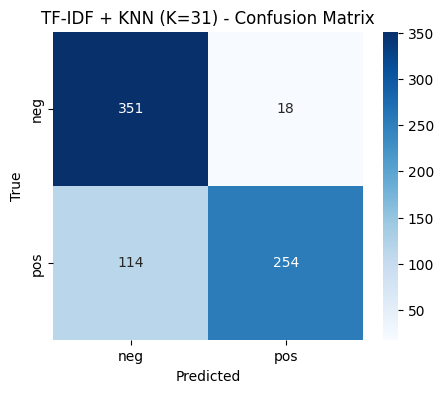

In [ ]:
# ==========================================
# EVALUASI KNN + TF-IDF (PAKAI K TERBAIK CV)
# ==========================================

# Inisialisasi KNN dengan K terbaik hasil CV
knn_tfidf = KNeighborsClassifier(n_neighbors=best_k_tfidf)

# Training model
knn_tfidf.fit(X_train_tfidf, y_train)

# Prediksi
pred_tfidf = knn_tfidf.predict(X_test_tfidf)

# ====== METRIK ======
print("TF-IDF + KNN — Accuracy:", accuracy_score(y_test, pred_tfidf))
print("F1 macro:", f1_score(y_test, pred_tfidf, average='macro'))

print("\n=== Classification Report (TF-IDF + KNN) ===")
print(classification_report(y_test, pred_tfidf, target_names=['neg', 'pos']))

# ====== CONFUSION MATRIX ======
cm = confusion_matrix(y_test, pred_tfidf)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['neg', 'pos'],
    yticklabels=['neg', 'pos']
)
plt.title(f'TF-IDF + KNN (K={best_k_tfidf}) - Confusion Matrix')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## **IndoBERT + KNN**

K=1 | f1_macro CV mean: 0.8586
K=3 | f1_macro CV mean: 0.8749
K=5 | f1_macro CV mean: 0.8834
K=7 | f1_macro CV mean: 0.8864
K=9 | f1_macro CV mean: 0.8881
K=11 | f1_macro CV mean: 0.8912
K=13 | f1_macro CV mean: 0.8946
K=15 | f1_macro CV mean: 0.8973
K=17 | f1_macro CV mean: 0.9014
K=19 | f1_macro CV mean: 0.8984
K=21 | f1_macro CV mean: 0.8967
K=23 | f1_macro CV mean: 0.8939
K=25 | f1_macro CV mean: 0.8956
K=27 | f1_macro CV mean: 0.8899
K=29 | f1_macro CV mean: 0.8967
K=31 | f1_macro CV mean: 0.8933

=== HASIL K TERBAIK INDO BERT (CV) ===
Best K: 17
F1-macro terbaik: 0.9014008039734229


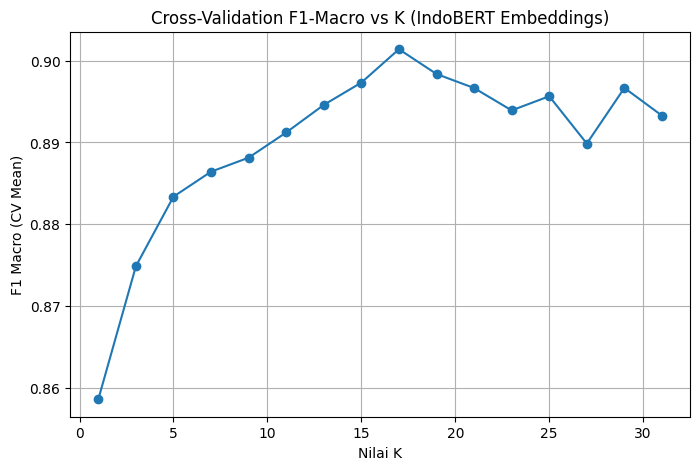

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# ======================================================
# Fungsi: Mencari K terbaik menggunakan Cross-Validation
# ======================================================
def get_best_k_cv(X_train, y_train, k_values, cv=5):
    k_scores = {}
    best_k = None
    best_score = -1

    for k in k_values:
        model = KNeighborsClassifier(n_neighbors=k)
        scores = cross_val_score(
            model, X_train, y_train,
            cv=cv,
            scoring='f1_macro',
            n_jobs=-1
        )

        mean_score = scores.mean()
        k_scores[k] = mean_score

        print(f"K={k} | f1_macro CV mean: {mean_score:.4f}")

        if mean_score > best_score:
            best_score = mean_score
            best_k = k

    return best_k, k_scores


# =============================
# 1. Tentukan daftar nilai K
# =============================
k_values = list(range(1, 32, 2))  # hanya K ganjil, 1–31

# =============================
# 2. Jalankan pencarian K terbaik
# =============================
best_k_bert, score_dict_bert = get_best_k_cv(
    X_train_bert, y_train, k_values
)

print("\n=== HASIL K TERBAIK INDO BERT (CV) ===")
print("Best K:", best_k_bert)
print("F1-macro terbaik:", score_dict_bert[best_k_bert])

# =============================
# 3. Plot hasil CV untuk visualisasi
# =============================
plt.figure(figsize=(8, 5))
plt.plot(list(score_dict_bert.keys()), list(score_dict_bert.values()), marker='o')
plt.xlabel("Nilai K")
plt.ylabel("F1 Macro (CV Mean)")
plt.title("Cross-Validation F1-Macro vs K (IndoBERT Embeddings)")
plt.grid(True)
plt.show()

IndoBERT + KNN — Accuracy: 0.903663500678426
F1 macro: 0.9035775818384514

=== Classification Report (IndoBERT + KNN) ===
              precision    recall  f1-score   support

         neg       0.93      0.87      0.90       369
         pos       0.88      0.93      0.91       368

    accuracy                           0.90       737
   macro avg       0.91      0.90      0.90       737
weighted avg       0.91      0.90      0.90       737



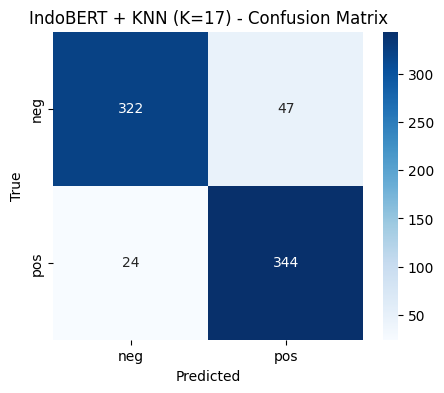

In [ ]:
# ==========================================
# EVALUASI KNN + INDOBERT (PAKAI K TERBAIK CV)
# ==========================================

knn_bert = KNeighborsClassifier(n_neighbors=best_k_bert)

# train model
knn_bert.fit(X_train_bert, y_train)

# prediksi pada data test
pred_bert = knn_bert.predict(X_test_bert)

# ===== METRIK =====
print("IndoBERT + KNN — Accuracy:", accuracy_score(y_test, pred_bert))
print("F1 macro:", f1_score(y_test, pred_bert, average='macro'))

print("\n=== Classification Report (IndoBERT + KNN) ===")
print(classification_report(y_test, pred_bert, target_names=['neg', 'pos']))

# ===== CONFUSION MATRIX =====
cm = confusion_matrix(y_test, pred_bert)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['neg', 'pos'],
            yticklabels=['neg', 'pos'])
plt.title(f'IndoBERT + KNN (K={best_k_bert}) - Confusion Matrix')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# **Perbandingan Hasil**

In [ ]:
def metrics_for(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'precision_macro': precision_score(y_true, y_pred, average='macro'),
        'recall_macro': recall_score(y_true, y_pred, average='macro')
    }

results = {
    'TF-IDF + KNN': metrics_for(y_test, pred_tfidf),
    'IndoBERT + KNN': metrics_for(y_test, pred_bert),
}

results_df = pd.DataFrame(results).T
display(results_df)

,accuracy,f1_macro,precision_macro,recall_macro
TF-IDF + KNN,0.820896,0.817738,0.844331,0.820718
IndoBERT + KNN,0.903664,0.903578,0.905216,0.903706


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

def metrics_full(y_true, y_pred):
    """
    Menghasilkan metrik evaluasi lengkap:
    - Accuracy
    - Macro Precision, Recall, F1
    - Precision, Recall, F1 per kelas (negatif & positif)
    """

    report = classification_report(
        y_true,
        y_pred,
        target_names=['neg', 'pos'],
        output_dict=True
    )

    return {
        # ============================
        # METRIK GLOBAL
        # ============================
        'accuracy': accuracy_score(y_true, y_pred),

        # ============================
        # METRIK MACRO
        # ============================
        'precision_macro': report['macro avg']['precision'],
        'recall_macro': report['macro avg']['recall'],
        'f1_macro': report['macro avg']['f1-score'],

        # ============================
        # KELAS NEGATIF
        # ============================
        'precision_neg': report['neg']['precision'],
        'recall_neg': report['neg']['recall'],
        'f1_neg': report['neg']['f1-score'],

        # ============================
        # KELAS POSITIF
        # ============================
        'precision_pos': report['pos']['precision'],
        'recall_pos': report['pos']['recall'],
        'f1_pos': report['pos']['f1-score'],
    }

results = {
    'TF-IDF + KNN': metrics_full(y_test, pred_tfidf),
    'IndoBERT + KNN': metrics_full(y_test, pred_bert),
}

results_df = pd.DataFrame(results).T
display(results_df.round(3))

,accuracy,precision_macro,recall_macro,f1_macro,precision_neg,recall_neg,f1_neg,precision_pos,recall_pos,f1_pos
TF-IDF + KNN,0.821,0.844,0.821,0.818,0.755,0.951,0.842,0.934,0.690,0.794
IndoBERT + KNN,0.904,0.905,0.904,0.904,0.931,0.873,0.901,0.880,0.935,0.906


# **Simpan Model**

In [ ]:
import joblib
import os

# ============================================================
# Folder tujuan penyimpanan model (Google Drive)
# ============================================================
MODEL_DIR = "/content/drive/MyDrive/1.KULIAH/TA/data2/analisis/model"
os.makedirs(MODEL_DIR, exist_ok=True)

print("Folder penyimpanan model:", MODEL_DIR)

# ============================================================
# Simpan model KNN IndoBERT
# ============================================================
MODEL_PATH = os.path.join(MODEL_DIR, "knn_indobert.pkl")

joblib.dump(knn_bert, MODEL_PATH)

print("Model KNN IndoBERT berhasil disimpan di:")
print(MODEL_PATH)

Folder penyimpanan model: /content/drive/MyDrive/1.KULIAH/TA/data2/analisis/model
Model KNN IndoBERT berhasil disimpan di:
/content/drive/MyDrive/1.KULIAH/TA/data2/analisis/model/knn_indobert.pkl


In [ ]:
from transformers import AutoTokenizer, AutoModel
import os

MODEL_NAME = "indobenchmark/indobert-base-p2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

SAVE_DIR = "/content/drive/MyDrive/1.KULIAH/TA/data2/analisis/model/indobert"
os.makedirs(SAVE_DIR, exist_ok=True)

tokenizer.save_pretrained(SAVE_DIR)
model.save_pretrained(SAVE_DIR)

print("IndoBERT tokenizer & model berhasil disimpan di Drive:")
print(SAVE_DIR)

IndoBERT tokenizer & model berhasil disimpan di Drive:
/content/drive/MyDrive/1.KULIAH/TA/data2/analisis/model/indobert
